In [4]:
import numpy as np
import pandas as pd

In [5]:
data = {
    'study_hours': [1,2,3,4,5,6,7,8,2,3],
    'attendance': [50,60,65,70,80,85,90,95,55,60],
    'assignment': [40,50,55,60,70,75,80,90,45,50],
    'result': [0,0,0,1,1,1,1,1,0,0]   # 0 = Fail, 1 = Pass
}

df = pd.DataFrame(data)
print(df.head())

   study_hours  attendance  assignment  result
0            1          50          40       0
1            2          60          50       0
2            3          65          55       0
3            4          70          60       1
4            5          80          70       1


In [9]:
x=df[['study_hours','attendance','assignment']]
y=df['result']
from tensorflow.keras.layers import Dense,Dropout

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
model=Sequential([#empty model
   Dense(12,activation="relu",input_shape=(3,)),
   Dropout(0.5),
   Dense(6,activation="relu"),
   Dropout(0.5),
   Dense(3,activation="relu"),
   Dropout(0.5),
   Dense(1,activation='sigmoid')
])
    

C:\Users\Nandini b m\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
#compile
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [21]:
#train model
h=model.fit(x_train,y_train,epochs=6,verbose=1)

Epoch 1/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3750 - loss: 21.0789
Epoch 2/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5000 - loss: 43.6491
Epoch 3/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5000 - loss: 29.1434
Epoch 4/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.2500 - loss: 15.9097
Epoch 5/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5000 - loss: 5.9572
Epoch 6/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5000 - loss: 36.6247


In [26]:
y_pred=(model.predict(x_test)>0.5).astype("int32")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


In [27]:
loss,accuracy=model.evaluate(x_test,y_pred)
print("accuracy=",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 1.0000 - loss: 4.1698e-13
accuracy= 1.0


In [32]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print("confusion matrix:",cm)

confusion matrix: [[0 2]
 [0 0]]


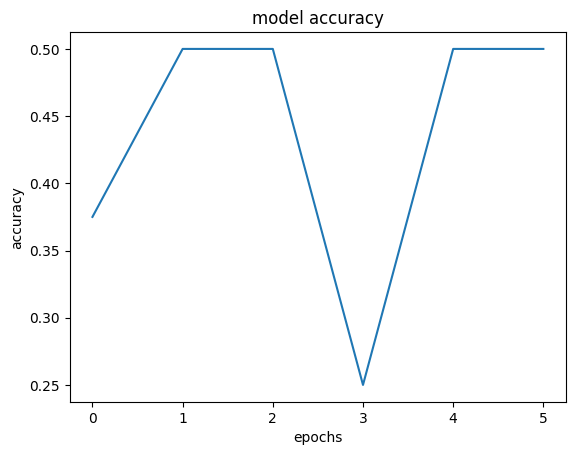

In [35]:
import matplotlib.pyplot as plt
#baseline performance
plt.plot(h.history['accuracy'])
plt.title('model accuracy')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.show()

